In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
from cycler import cycler
from scipy.stats import wasserstein_distance, binom

In [2]:
from scipy.stats import ks_2samp


In [3]:
# define your plot style

best_style = {
    "font.family": "sans-serif",
    "mathtext.fontset": "custom",
    "mathtext.rm": "TeX Gyre Heros",
    "mathtext.bf": "TeX Gyre Heros:bold",
    "mathtext.sf": "TeX Gyre Heros",
    "mathtext.it": "TeX Gyre Heros:italic",
    "mathtext.tt": "TeX Gyre Heros",
    "mathtext.cal": "TeX Gyre Heros",
    "mathtext.default": "regular",
    "figure.figsize": (10.0, 10.0),
    "font.size": 26,
    "axes.labelsize": "medium",
    "axes.unicode_minus": False,
    "xtick.labelsize": "small",
    "ytick.labelsize": "small",
    "legend.fontsize": "small",
    "legend.handlelength": 1.5,
    "legend.borderpad": 0.5,
    "xtick.direction": "in",
    "xtick.major.size": 12,
    "xtick.minor.size": 6,
    "xtick.major.pad": 6,
    "xtick.top": True,
    "xtick.major.top": True,
    "xtick.major.bottom": True,
    "xtick.minor.top": True,
    "xtick.minor.bottom": True,
    "xtick.minor.visible": True,
    "ytick.direction": "in",
    "ytick.major.size": 12,
    "ytick.minor.size": 6.0,
    "ytick.right": True,
    "ytick.major.left": True,
    "ytick.major.right": True,
    "ytick.minor.left": True,
    "ytick.minor.right": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.8,
    "grid.linestyle": ":",
    "axes.linewidth": 2,
    "savefig.transparent": False,
}
plt.style.use(best_style)
cols = ["#5790fc", "#f89c20", "#009e73", "#e42536", "#9c9ca1", "#964a8b",  "#7a21dd"]
# add a new color blind friendly color to this list
#set cols as the matplotlib default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cols)

In [4]:
region = 'region9'
datadir = "region9_narrowprior"
# region = 'entire_region'
# datadir = "entire_region_narrowprior_wom"
model_name = "entire_region_narrowprior"

posterior_path = f'/deepskieslab/stronglensing/hsbi/nre_posterior/{model_name}/'

In [5]:
figpath = f'/deepskieslab/stronglensing/hsbi/models/plots/evaluate/{model_name}/{datadir}/'

### without calibration

In [6]:
posterior_data = np.load(posterior_path+f'{datadir}_mcmc.npz')
flat_samples_list = posterior_data['flat_samples_list']
samples_w_list = posterior_data['samples_w_list']
samples_om_list = posterior_data['samples_om_list']
true_w_list = posterior_data['true_w_list']
true_om_list = posterior_data['true_om_list']

In [7]:
# calculate the median and the 16th and 84th percentile of the samples
w_median_list = []
w_16_list = []
w_84_list = []
om_median_list = []
om_16_list = []
om_84_list = []

for i in range(0, samples_w_list.shape[0]):
    w_median = np.median(samples_w_list[i])
    w_16, w_84 = np.percentile(samples_w_list[i], [16, 84])
    om_median = np.median(samples_om_list[i])
    om_16, om_84 = np.percentile(samples_om_list[i], [16, 84])

    w_median_list.append(w_median)
    w_16_list.append(w_16)
    w_84_list.append(w_84)

    om_median_list.append(om_median)
    om_16_list.append(om_16)
    om_84_list.append(om_84)

w_median_list = np.array(w_median_list)
w_16_list = np.array(w_16_list)
w_84_list = np.array(w_84_list)
om_median_list = np.array(om_median_list)
om_16_list = np.array(om_16_list)
om_84_list = np.array(om_84_list)

### with calibration

In [8]:
alpha = 0.175255
beta = 0.11896
posterior_data_calib = np.load(posterior_path+f'{datadir}_mcmc_calibration_alpha{str(alpha)}_beta{str(beta)}.npz')
flat_samples_list_calib = posterior_data_calib['flat_samples_list']
samples_w_list_calib = posterior_data_calib['samples_w_list']
samples_om_list_calib = posterior_data_calib['samples_om_list']
true_w_list_calib = posterior_data_calib['true_w_list']
true_om_list_calib = posterior_data_calib['true_om_list']

In [9]:
# get the median and the 16th and 84th percentile of the samples after calibration
w_median_list_calib = []
w_16_list_calib = []
w_84_list_calib = []
om_median_list_calib = []
om_16_list_calib = []
om_84_list_calib = []   

for i in range(0, samples_w_list_calib.shape[0]):
    w_median = np.median(samples_w_list_calib[i])
    w_16, w_84 = np.percentile(samples_w_list_calib[i], [16, 84])
    om_median = np.median(samples_om_list_calib[i])
    om_16, om_84 = np.percentile(samples_om_list_calib[i], [16, 84])

    w_median_list_calib.append(w_median)
    w_16_list_calib.append(w_16)
    w_84_list_calib.append(w_84)

    om_median_list_calib.append(om_median)
    om_16_list_calib.append(om_16)
    om_84_list_calib.append(om_84)  

w_median_list_calib = np.array(w_median_list_calib)
w_16_list_calib = np.array(w_16_list_calib) 
w_84_list_calib = np.array(w_84_list_calib)
om_median_list_calib = np.array(om_median_list_calib)
om_16_list_calib = np.array(om_16_list_calib)
om_84_list_calib = np.array(om_84_list_calib)

In [10]:
# check if true_w_list and true_w_list_calib are the same
print("Check if true_w_list and true_w_list_calib are the same:")
print(np.array_equal(true_w_list, true_w_list_calib))
print("Check if true_om_list and true_om_list_calib are the same:")
print(np.array_equal(true_om_list, true_om_list_calib))

Check if true_w_list and true_w_list_calib are the same:
True
Check if true_om_list and true_om_list_calib are the same:
True


findfont: Font family ['TeX Gyre Heros'] not found. Falling back to DejaVu Sans.
findfont: Font family ['TeX Gyre Heros'] not found. Falling back to DejaVu Sans.
findfont: Font family ['TeX Gyre Heros'] not found. Falling back to DejaVu Sans.


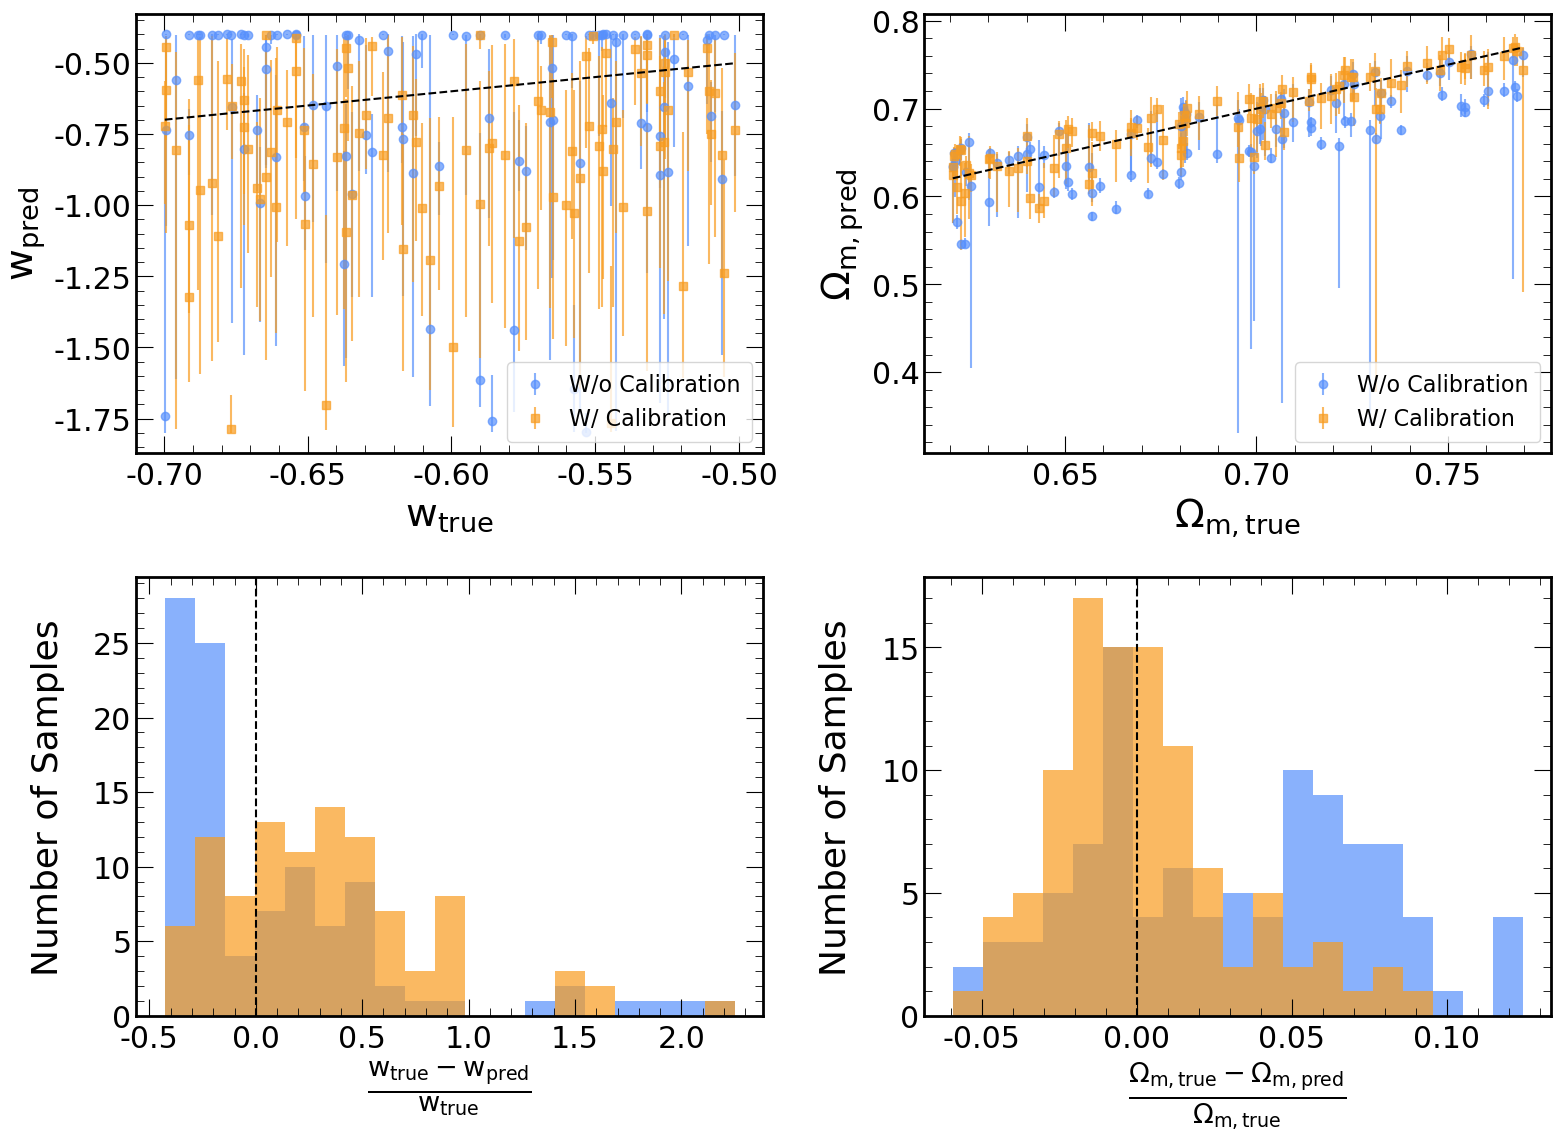

In [11]:
# plot the median predicted vs true values with error bars showing 16th and 84th percentiles
fig, ((ax00, ax01), (ax10, ax11)) = plt.subplots(2, 2, figsize=(16, 12))
# Top row: true vs predicted
# ax00.errorbar(true_w_list, w_mean_list, yerr=w_std_list, fmt='o', label='W/o Calibration', color='C0', alpha=0.7) 
# plot the error bars as the 16th and 84th percentiles instead of std
ax00.errorbar(true_w_list, w_median_list, yerr=[w_median_list - w_16_list, w_84_list - w_median_list], fmt='o', label='W/o Calibration', color='C0', alpha=0.7) 
ax00.errorbar(true_w_list_calib, w_median_list_calib, yerr=[w_median_list_calib - w_16_list_calib, w_84_list_calib - w_median_list_calib], fmt='s', label='W/ Calibration', color='C1', alpha=0.7) 
ax00.plot([true_w_list.min(), true_w_list.max()], [true_w_list.min(), true_w_list.max()], 'k--', zorder=5)
ax00.set_ylabel(r'$w_{pred}$', fontsize=28)
ax00.set_xlabel(r'$w_{true}$', fontsize=28)
# ax00.set_ylim(true_w_list.min()-0.5, true_w_list.max()+0.5)
ax00.legend(loc='lower right', fontsize=16)  
# ax10.errorbar(true_om_list, om_mean_list, yerr=om_std_list, fmt='o', label='W/o Calibration', color='C0', alpha=0.7)
# ax10.errorbar(true_om_list_calib, om_mean_list_calib, yerr=om_std_list_calib, fmt='s', label='W/ Calibration', color='C1', alpha=0.7)
ax01.errorbar(true_om_list, om_median_list, yerr=[om_median_list - om_16_list, om_84_list - om_median_list], fmt='o', label='W/o Calibration', color='C0', alpha=0.7)
ax01.errorbar(true_om_list_calib, om_median_list_calib, yerr=[om_median_list_calib - om_16_list_calib, om_84_list_calib - om_median_list_calib], fmt='s', label='W/ Calibration', color='C1', alpha=0.7)
ax01.plot([true_om_list.min(), true_om_list.max()], [true_om_list.min(), true_om_list.max()], 'k--', zorder=5)
ax01.set_ylabel(r'$\Omega_{m,pred}$', fontsize=28)
ax01.set_xlabel(r'$\Omega_{m,true}$', fontsize=28)
ax01.legend(loc='lower right', fontsize=16)
# Bottom row: histogram of true - median predicted

# ax10.hist(true_w_list - w_median_list, alpha=0.7, label='W/o Calibration', color='C0', bins=15)
# ax10.hist(true_w_list_calib - w_median_list_calib, alpha=0.7, label='W/ Calibration', color='C1', bins=15)

# data1 = true_w_list - w_median_list
# data2 = true_w_list_calib - w_median_list_calib
data1 = (true_w_list - w_median_list)/np.abs(true_w_list)
data2 = (true_w_list_calib - w_median_list_calib)/np.abs(true_w_list_calib)
xmin = min(data1.min(), data2.min())
xmax = max(data1.max(), data2.max())
bins = np.linspace(xmin, xmax, 20)

# Compute histograms and normalize peaks to 1.0
hist1, _ = np.histogram(data1, bins=bins)
hist2, _ = np.histogram(data2, bins=bins)
# hist1 = hist1 / hist1.max()
# hist2 = hist2 / hist2.max()

# Plot using axes.hist
ax10.hist(bins[:-1], bins, weights=hist1, alpha=0.7, label='W/o Calibration', color='C0')
ax10.hist(bins[:-1], bins, weights=hist2, alpha=0.7, label='W/ Calibration', color='C1')


ax10.set_xlabel(r'$\frac{w_{true} - w_{pred}}{w_{true}}$', fontsize=28)
ax10.set_ylabel('Number of Samples', fontsize=26, labelpad=20)
ax10.axvline(0, color='k', linestyle='--', lw=1.5)

# ax11.hist(true_om_list - om_median_list, alpha=0.7, label='W/o Calibration', color='C0', bins=15, density=True, stacked=True)
# ax11.hist(true_om_list_calib - om_median_list_calib, alpha=0.7, label='W/ Calibration', color='C1', bins=15, density=True, stacked=True)
data1 = (true_om_list - om_median_list)/np.abs(true_om_list)
data2 = (true_om_list_calib - om_median_list_calib)/np.abs(true_om_list_calib)
xmin = min(data1.min(), data2.min())
xmax = max(data1.max(), data2.max())
bins = np.linspace(xmin, xmax, 20)  
# Compute histograms and normalize peaks to 1.0
hist1, _ = np.histogram(data1, bins=bins)
hist2, _ = np.histogram(data2, bins=bins)
# hist1 = hist1 / hist1.max()
# hist2 = hist2 / hist2.max()     
# Plot using axes.hist
ax11.hist(bins[:-1], bins, weights=hist1, alpha=0.7, label='W/o Calibration', color='C0')
ax11.hist(bins[:-1], bins, weights=hist2, alpha=0.7, label='W/ Calibration', color='C1')

ax11.set_xlabel(r'$\frac{\Omega_{m,true} - \Omega_{m,pred}}{\Omega_{m,true}}$', fontsize=28)
ax11.set_ylabel('Number of Samples', fontsize=26, labelpad=20)
ax11.axvline(0, color='k', linestyle='--', lw=1.5)
# ax11.legend(loc='upper right')
plt.tight_layout()
# plt.show()
plt.savefig(figpath+region+"_parity_residuals_histogram_median.pdf", dpi=300)

In [12]:
# calculate the rank statistic for w and om before and after calibration
def calculate_rank(true_values, samples_list):
    ranks = []
    for i in range(len(true_values)):
        samples = samples_list[i]
        true_value = true_values[i]
        rank = np.sum(samples < true_value)
        ranks.append(rank)
    return np.array(ranks)

# plot the rank histograms
ranks_w = calculate_rank(true_w_list, samples_w_list)
ranks_w_calib = calculate_rank(true_w_list_calib, samples_w_list_calib)
ranks_om = calculate_rank(true_om_list, samples_om_list)
ranks_om_calib = calculate_rank(true_om_list_calib, samples_om_list_calib)  

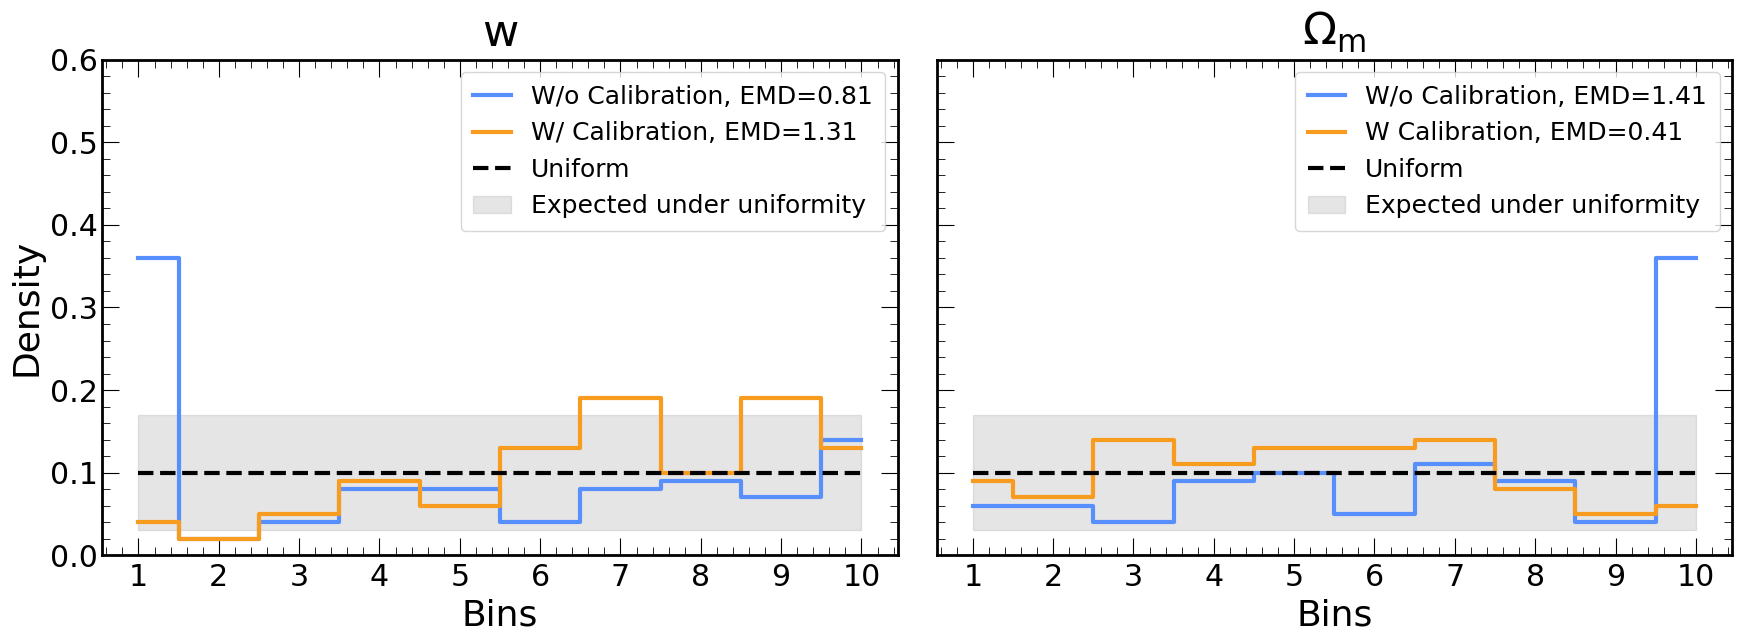

In [13]:
N = len(ranks_w)  # number of objects
# n_bins = int(N / 5)
n_bins = int(N / 10)

# Bin edges and centers
bins = np.arange(n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Bin the ranks for w
binned_ranks_w, _ = np.histogram(ranks_w, bins=n_bins)
binned_ranks_w = binned_ranks_w / np.sum(binned_ranks_w)
binned_ranks_w_calib, _ = np.histogram(ranks_w_calib, bins=n_bins)
binned_ranks_w_calib = binned_ranks_w_calib / np.sum(binned_ranks_w_calib)

# Bin the ranks for omega
binned_ranks_om, _ = np.histogram(ranks_om, bins=n_bins)
binned_ranks_om = binned_ranks_om / np.sum(binned_ranks_om)
binned_ranks_om_calib, _ = np.histogram(ranks_om_calib, bins=n_bins)
binned_ranks_om_calib = binned_ranks_om_calib / np.sum(binned_ranks_om_calib)

binned_uniform = np.ones(n_bins) / n_bins

emd_w = wasserstein_distance(bins[:-1], bins[:-1], binned_ranks_w, binned_uniform)
emd_w_calib = wasserstein_distance(bins[:-1], bins[:-1], binned_ranks_w_calib, binned_uniform)
emd_om = wasserstein_distance(bins[:-1], bins[:-1], binned_ranks_om, binned_uniform)
emd_om_calib = wasserstein_distance(bins[:-1], bins[:-1], binned_ranks_om_calib, binned_uniform)

# # K-S distance for w
# ks_w = ks_2samp(binned_ranks_w, binned_uniform)
# ks_w_calib = ks_2samp(binned_ranks_w_calib, binned_uniform)

# print("KS statistics for w: ", ks_w)
# print("KS statistics for w after calibration: ", ks_w_calib)

# # K-S distance for omega
# ks_om = ks_2samp(binned_ranks_om, binned_uniform)
# ks_om_calib = ks_2samp(binned_ranks_om_calib, binned_uniform)

# print("KS statistics for omega: ", ks_om)
# print("KS statistics for omega after calibration: ", ks_om_calib)


fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)  # Increased figure size


# plot the histogram region expected under uniformity
lower = binom(N, p=1 / (n_bins + 1)).ppf(0.005)/N
upper = binom(N, p=1 / (n_bins + 1)).ppf(0.995)/N

# fill color in step 

axes[0].step(
    bin_centers, binned_ranks_w, where='mid',
    label=rf'W/o Calibration, EMD={emd_w:.2f}', color='C0', linewidth=3, 
)   
axes[0].step(
    bin_centers, binned_ranks_w_calib, where='mid',
    label=rf'W/ Calibration, EMD={emd_w_calib:.2f}', color='C1', linewidth=3,
)
axes[0].step(
    bin_centers, binned_uniform, where='mid',
    label='Uniform', color='k', linestyle='--', linewidth=3,
)
# axes[0].fill_between(bin_centers, lower_bound, upper_bound, color='gray', alpha=0.4, label='99% Band')  # Commented out
axes[0].set_xlabel('Bins')
axes[0].set_ylabel('Density')
axes[0].set_title(r'$w$', fontsize= 32, pad=10)
# show tick labels 1 to 10 on x axis
axes[0].set_xticks(bin_centers)
axes[0].set_xticklabels(range(1, n_bins + 1))
axes[0].set_ylim(0.0, 0.6)

# fill between lower and upper bounds
axes[0].fill_between(bin_centers, lower, upper, color='gray', alpha=0.2, label='Expected under uniformity')

axes[0].legend(fontsize=18, loc='upper right')

axes[1].step(
    bin_centers, binned_ranks_om, where='mid',
    label=rf'W/o Calibration, EMD={emd_om:.2f}', color='C0', linewidth=3,
)   
axes[1].step(
    bin_centers, binned_ranks_om_calib, where='mid',  
    label=rf'W Calibration, EMD={emd_om_calib:.2f}', color='C1', linewidth=3, 
)   
axes[1].step(
    bin_centers, binned_uniform, where='mid',
    label='Uniform', color='k', linestyle='--', linewidth=3,
)
# axes[1].fill_between(bin_centers, lower_bound, upper_bound, color='gray', alpha=0.4, label='99% Band')  # Commented out
axes[1].set_xlabel('Bins')
axes[1].set_title(r'$\Omega_m$', fontsize= 32, pad=10)
# show tick labels 1 to 10 on x axis
axes[1].set_xticks(bin_centers)
axes[1].set_xticklabels(range(1, n_bins + 1))
axes[1].fill_between(bin_centers, lower, upper, color='gray', alpha=0.2, label='Expected under uniformity')
axes[1].legend(fontsize=18, loc='upper right')



plt.tight_layout()
# plt.show()
plt.savefig(figpath+region+'_rank_histogram.pdf', dpi=300)

In [ ]:
# def plot_joint_with_marginals_median(
#     flat_samples_list,
#     flat_samples_list_calib,
#     true_w_list,
#     true_om_list,
#     w_median_list,
#     om_median_list,
#     w_median_list_calib,
#     om_median_list_calib,
#     w_16_list,
#     w_84_list,
#     om_16_list,
#     om_84_list,
#     w_16_list_calib,
#     w_84_list_calib,
#     om_16_list_calib,
#     om_84_list_calib,
#     n=None,
#     color="steelblue",     # use steelblue for contours and histograms
#     figsize_per_cell=3.5,
#     bins=50,
# ):
#     """
#     Plot an n x n grid of corner plots for pairs (Ωm, w).
#     Each cell shows: joint posterior (contours at 68/95/99.7%) and marginal posteriors,
#     with true lines and truth marker overlaid.

#     Styling tweaks:
#       - Contours and histograms in steelblue
#       - Reduced label size and tick lengths
#       - Show tick labels for all plots
#       - Histogram axes: ticks only on the bottom (top ticks off)
#     """
#     N = len(flat_samples_list)
#     if N == 0:
#         raise ValueError("flat_samples_list is empty; nothing to plot.")

#     import math
#     if n is None:
#         n = int(math.ceil(math.sqrt(N)))
#     n_total = min(N, n * n)

#     # Outer grid
#     fig = plt.figure(figsize=(n * figsize_per_cell, n * figsize_per_cell))
#     outer = fig.add_gridspec(n, n, wspace=0.3, hspace=0.3)

#     for k in range(n_total):
#         r, cidx = divmod(k, n)
#         subfig = fig.add_subfigure(outer[r, cidx])

#         fig_corner = corner.corner(flat_samples_list[k], fig=subfig,
#                 labels=[r"$\Omega_{m}$", r"$w$" ], 
#                         color=color, hist_kwargs={'density':True}, alpha=0.1, plot_contours=True, plot_datapoints=False,
#                         levels=[0.682], smooth=1.0, label_kwargs={"fontsize": 10})
        
#         corner.corner(
#             flat_samples_list_calib[k],
#             fig=fig_corner,
#             labels=[r"$\Omega_{m}$", r"$w$"],
#             color='orange',
#             hist_kwargs={"density": True},  
#             contour_kwargs={"colors": 'orange', "linewidths": 1.5},
#             alpha=0.1,
#             plot_contours=True,
#             plot_datapoints=False,
#             levels=[0.682],
#             smooth=1.0,
#         )

#         # reduce tick label size for all axes
#         for ax in fig_corner.get_axes():
#             ax.tick_params(axis="both", which="both", labelsize=8)
        
        

#         # 2x2 axes (Ωm marginal |  , joint;  , w marginal)
#         axes = np.array(fig_corner.axes).reshape((2, 2))

#         # reduce the font size of the axes labels
#         axes[1, 1].set_xlabel(r"$\Omega_{m}$", fontsize=12)
#         axes[1, 0].set_xlabel(r"$w$", fontsize=12)
#         axes[1, 0].set_ylabel(r"$\Omega_{m}$", fontsize=12)

#         # axes[1, 1].xaxis.labelpad = 30
#         # axes[1, 0].xaxis.labelpad = 30
#         # axes[1, 0].yaxis.labelpad = 30

#         # Move x-labels and y-label further from axes
#         axes[1, 0].xaxis.set_label_coords(0.5, -0.36)   # x, y (y negative moves label down)
#         axes[1, 1].xaxis.set_label_coords(0.5, -0.36)
#         axes[1, 0].yaxis.set_label_coords(-0.36, 0.5)   # x negative moves label left


#         # Overlay true values
#         w_true = float(true_w_list[k])
#         om_true = float(true_om_list[k])

#         # omegam marginal (bottom-right)
#         axes[1, 1].axvline(om_true, linestyle="--", color="k", lw=1.5)
#         # w marginal (top-left)
#         axes[0, 0].axvline(w_true, linestyle="--", color="k", lw=1.5)
#         # Joint (bottom-left)
#         axes[1, 0].axvline(w_true, linestyle="--", color="k", lw=1.2)
#         axes[1, 0].axhline(om_true, linestyle="--", color="k", lw=1.2)
#         axes[1, 0].scatter(w_true, om_true, color="k", s=100, marker="*", zorder=5)

#         # show the mean of w and om as axvline in the marginals with and without calibration
#         w_mean = np.mean(flat_samples_list[k][:, 0])
#         om_mean = np.mean(flat_samples_list[k][:, 1])
#         axes[0, 0].axvline(w_mean, linestyle=":", color="steelblue", lw=1.5)
#         axes[1, 1].axvline(om_mean, linestyle=":", color="steelblue", lw=1.5)
#         w_median_calib = np.median(flat_samples_list_calib[k][:, 0])
#         om_median_calib = np.median(flat_samples_list_calib[k][:, 1])
#         axes[0, 0].axvline(w_median_calib, linestyle=":", color="orange", lw=1.5)
#         axes[1, 1].axvline(om_median_calib, linestyle=":", color="orange", lw=1.5)
        

#         # Ticks: show labels everywhere, reduce tick length
#         for ax in fig_corner.get_axes():
#             ax.tick_params(axis="both", which="both", labelsize=10, length=3)

#         # Histogram axes: ticks only on the bottom (remove top ticks)
#         axes[0, 0].tick_params(axis="x", top=False, bottom=True)  # Ωm marginal
#         axes[1, 1].tick_params(axis="x", top=False, bottom=True)  # w marginal

#         # Ensure tick labels are shown (override any global rc that hides them)
#         axes[0, 0].tick_params(labelbottom=True, labelleft=True)
#         axes[1, 0].tick_params(labelbottom=True, labelleft=True)
#         axes[1, 1].tick_params(labelbottom=True, labelleft=True)

#         # add legend only in the first plot axes[1,0]
#         if k == 0:
#             axes[0, 0].plot([], [], color="steelblue", label="W/o Calibration", lw=2)
#             axes[0, 0].plot([], [], color="orange", label="W/ Calibration", lw=2)
#             axes[0, 0].legend(loc="upper left", fontsize=8)

#         w_error_minus = w_median_list[k] - w_16_list[k]
#         w_error_plus = w_84_list[k] - w_median_list[k]
#         om_error_minus = om_median_list[k] - om_16_list[k]
#         om_error_plus = om_84_list[k] - om_median_list[k]
#         w_error_minus_calib = w_median_list_calib[k] - w_16_list_calib[k]
#         w_error_plus_calib = w_84_list_calib[k] - w_median_list_calib[k]
#         om_error_minus_calib = om_median_list_calib[k] - om_16_list_calib[k]
#         om_error_plus_calib = om_84_list_calib[k] - om_median_list_calib[k]

#         # show the true values and the median^{+84-median}_{-median-16} with and without calibration for w and om in axes[0, 1]
#         axes[0, 1].text(0.05, 1.0, r'$w_{true}=$' + f'{w_true:.2f}', transform=axes[0, 1].transAxes, fontsize=10, color='k')
#         axes[0, 1].text(0.05, 0.85, r'$w=$' + f'{w_median_list[k]:.2f}$^{{+{w_error_plus:.2f}}}_{{-{w_error_minus:.2f}}}$', transform=axes[0, 1].transAxes, fontsize=10, color='steelblue')
#         axes[0, 1].text(0.05, 0.65, r'$w=$' + f'{w_median_list_calib[k]:.2f}$^{{+{w_error_plus_calib:.2f}}}_{{-{w_error_minus_calib:.2f}}}$', transform=axes[0, 1].transAxes, fontsize=10, color='orange')
#         axes[0, 1].text(0.05, 0.45, r'$\Omega_{m,true}=$' + f'{om_true:.2f}', transform=axes[0, 1].transAxes, fontsize=10, color='k')
#         axes[0, 1].text(0.05, 0.25, r'$\Omega_{m}=$' + f'{om_median_list[k]:.2f}$^{{+{om_error_plus:.2f}}}_{{-{om_error_minus:.2f}}}$', transform=axes[0, 1].transAxes, fontsize=10, color='steelblue')
#         axes[0, 1].text(0.05, 0.05, r'$\Omega_{m}=$' + f'{om_median_list_calib[k]:.2f}$^{{+{om_error_plus_calib:.2f}}}_{{-{om_error_minus_calib:.2f}}}$', transform=axes[0, 1].transAxes, fontsize=10, color='orange')    
#     # plt.show()
#     plt.savefig(figpath+region+"_joint_marginals_median.pdf", dpi=300)

#     return 

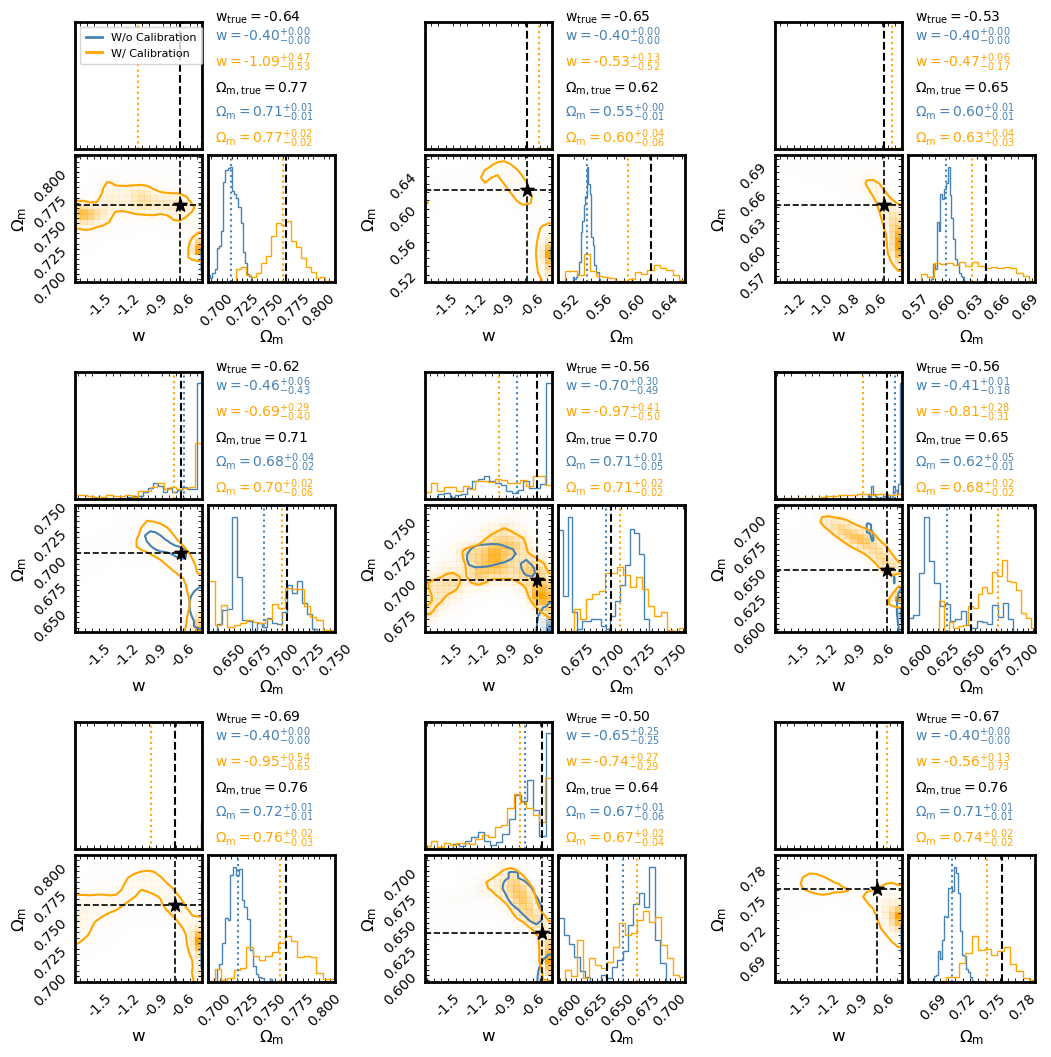

In [15]:
plot_joint_with_marginals_median(
    flat_samples_list=flat_samples_list,
    flat_samples_list_calib=flat_samples_list_calib,
    true_w_list=true_w_list,
    true_om_list=true_om_list,
    w_median_list=w_median_list,
    om_median_list=om_median_list,
    w_median_list_calib=w_median_list_calib,
    om_median_list_calib=om_median_list_calib,
    w_16_list=w_16_list,
    w_84_list=w_84_list,
    om_16_list=om_16_list,
    om_84_list=om_84_list,
    w_16_list_calib=w_16_list_calib,
    w_84_list_calib=w_84_list_calib,
    om_16_list_calib=om_16_list_calib,
    om_84_list_calib=om_84_list_calib,
    n=3)

In [24]:
# posterior coverage plot
def calculate_coverage_fraction_density_estimator(n_lenses, sampled_values_list, truth_array, percentile_list):
    # sample from posterior probability
    count_array = []
    for i in range(0, n_lenses):
        sampled_values = sampled_values_list[i]
        count_vector = []
        # print('pair: ', i+1)
        # print('truth : ', truth_array[i])
        for ind, cov in enumerate(percentile_list):
            percentile_l = 50.0 - cov/2
            percentile_u = 50.0 + cov/2 
            confidence_l = np.percentile(sampled_values,percentile_l,axis=0)
            confidence_u = np.percentile(sampled_values,percentile_u,axis=0)
            # print(confidence_l, confidence_u)
            count = np.logical_and(confidence_u - truth_array[i] > 0, truth_array[i] - confidence_l > 0)
            count_vector.append(count)
            # print(count)
        # print(i, count_vector)
        count_array.append(count_vector)
    count_sum_array = np.sum(count_array, axis=0)
    # print(count_sum_array)
    frac_lens_within_vol = np.array(count_sum_array)
    return frac_lens_within_vol/n_lenses

Calculating the coverage fraction...
Plotting the coverage fraction...


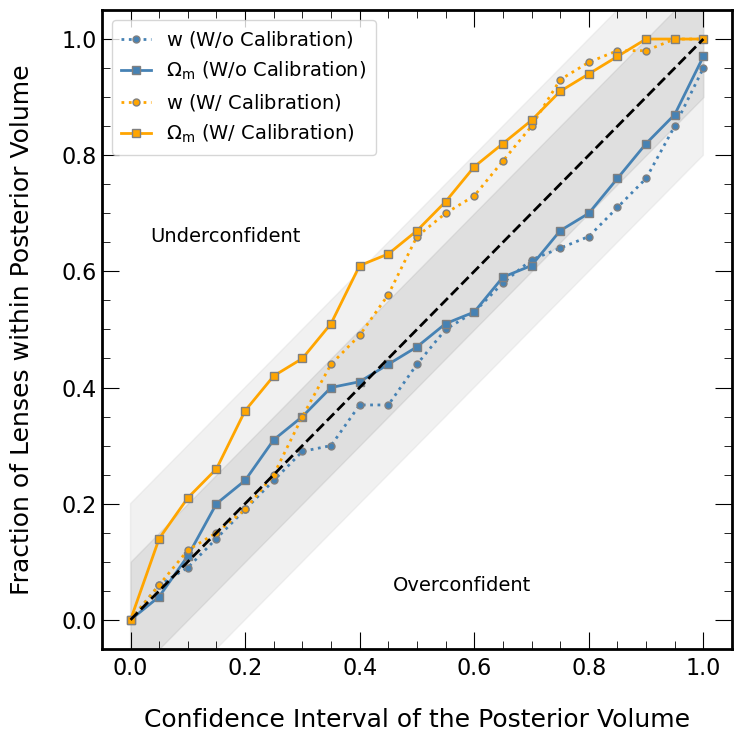

In [25]:
print("Calculating the coverage fraction...")
percentile_array = np.linspace(0,100,21)
n_pairs = len(true_w_list)
coverage_fraction_w = calculate_coverage_fraction_density_estimator(n_pairs, samples_w_list, 
                                                                true_w_list, percentile_array)
coverage_fraction_om = calculate_coverage_fraction_density_estimator(n_pairs, samples_om_list, true_om_list, 
                                                                    percentile_array)

# calculate coverage fraction with calibration
coverage_fraction_w_calib = calculate_coverage_fraction_density_estimator(n_pairs, samples_w_list_calib, 
                                                                true_w_list, percentile_array)
coverage_fraction_om_calib = calculate_coverage_fraction_density_estimator(n_pairs, samples_om_list_calib, true_om_list, 
                                                                    percentile_array)

print("Plotting the coverage fraction...")
percentile_array_norm = np.array(percentile_array)/100

default_cycler = (cycler(color='bgrcmyk') *
                    cycler(linestyle=['-', '-.']))

fig, ax = plt.subplots(1,1,figsize=(8, 8))
plt.plot(percentile_array_norm, coverage_fraction_w, marker='o', markersize=5, color='steelblue', 
         label=r'$w$ (W/o Calibration)', linestyle=':',  linewidth=2, markeredgecolor='grey')
plt.plot(percentile_array_norm, coverage_fraction_om, marker='s', markersize=6, color='steelblue', 
         label=r'$\Omega_m$ (W/o Calibration)', linestyle='-', linewidth=2, markeredgecolor='grey')
# plot with calibration
plt.plot(percentile_array_norm, coverage_fraction_w_calib, marker='o', markersize=5, color='orange', 
         label=r'$w$ (W/ Calibration)', linestyle=':', linewidth=2, markeredgecolor='grey')
plt.plot(percentile_array_norm, coverage_fraction_om_calib, marker='s', markersize=6, color='orange', 
         label=r'$\Omega_m$ (W/ Calibration)', linestyle='-', linewidth=2, markeredgecolor='grey')
plt.legend(loc='upper left', fontsize=14)
plt.plot([0,0.5,1],[0,0.5,1], 'k--', zorder=1000, linewidth=2)
plt.xlim([-0.05,1.05])
plt.ylim([-0.05,1.05])
plt.text(0.035,0.65,'Underconfident',horizontalalignment='left', fontsize=14)
plt.text(0.7,0.05,'Overconfident',horizontalalignment='right', fontsize=14)
plt.xlabel('Confidence Interval of the Posterior Volume', fontsize=18, labelpad=20)
plt.ylabel('Fraction of Lenses within Posterior Volume', fontsize=18, labelpad=20)

# plot thresholdsof10%(darkgray)and20%(lightgray)uncertainty miscalibration along the diagonal
x = np.linspace(0,1,100)
y1 = x - 0.1
y2 = x + 0.1
ax.fill_between(x, y1, y2, color='darkgray', alpha=0.3)  
y3 = x - 0.2
y4 = x + 0.2
ax.fill_between(x, y3, y4, color='lightgray', alpha=0.3)

ax.tick_params(axis='both', which='both', labelsize=16)
plt.tight_layout()
# plt.show()
plt.savefig(figpath+region+'_posterior_coverage_plot.pdf', dpi=300)